In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

3.26

Iter 1, weight: 3.8
Iter 2, weight: 3.08
Iter 3, weight: 2.648
Iter 4, weight: 2.3888000000000003


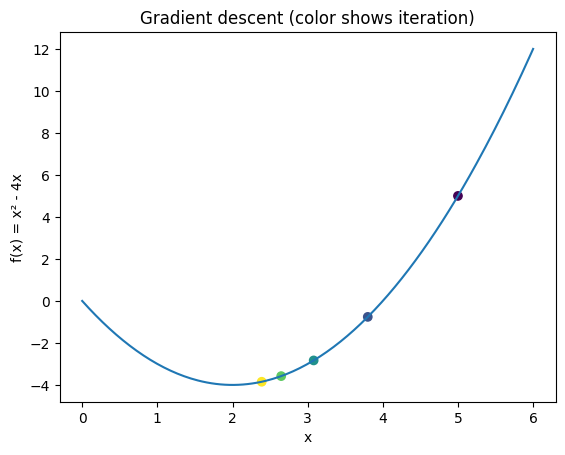

In [10]:
x0 = 5
eta = 0.2
x_history = [x0]

for i in range(4):
    gradient = 2*x0 - 4
    x0 = x0 - eta*gradient
    x_history.append(x0)
    print(f"Iter {i+1}, weight: {x0}")

x = np.linspace(0, 6, 200)
plt.plot(x, x**2 - 4*x)
plt.scatter(x_history, [v**2 - 4*v for v in x_history], c=range(len(x_history)), cmap="viridis")
plt.xlabel("x")
plt.ylabel("f(x) = x² - 4x")
plt.title("Gradient descent (color shows iteration)")
plt.show()


3.27

In [33]:
w = np.array([1, 2, -10])
x = np.array([3, 4, 1])

rawValue = np.dot(w.T, x)
label = np.sign(rawValue)
print(f"Raw value: {rawValue}, Label: {label}, if true label is -1 then the classification is {"correct" if label == -1 else "incorrect"}")

Raw value: 1, Label: 1, if true label is -1 then the classification is incorrect


3.28

In [37]:
w = np.array([-2, 1, 0])
x = np.array([2, 3, 1])
y = 1

rawValue = np.dot(w.T, x)
label = np.sign(rawValue)
print(f"Raw value: {rawValue}, Label: {label}, if true label is 1 then the classification is {"correct" if label == 1 else "incorrect"}")
w = w + y*x
print(f"New value: {np.dot(w.T, x)}, label: {np.sign(np.dot(w.T, x))}")

Raw value: -1, Label: -1, if true label is 1 then the classification is incorrect
New value: 13, label: 1


3.29

In [133]:
class Perceptron:
    def __init__(self, w_init, epochs):
        self.weight = [w_init]
        self.epochs = epochs
        self.errorHistory = []

    def predict(self, W, x):
        return np.sign(np.dot(W.T, x))
    
    def fit(self, X, y):
        d = X.shape[0]
        N = X.shape[1]
        _iter = 0
        missPoints = []
        for _ in range(self.epochs):
            currMiss = []
            mixID = np.random.permutation(N)
            for i in range(N):
                xi = X[:, mixID[i]].reshape(d, 1)
                yi = y[mixID[i]]
                if self.predict(self.weight[-1], xi) != yi:
                    currMiss.append(mixID[i])
                    w_new = self.weight[-1] + yi*xi
                    self.weight.append(w_new)

            _iter +=1
            print(f"iter {_iter}, current weight: {self.weight[-1]}, miss_points = {currMiss}")
            missPoints.append(currMiss)
            currMiss = []
            if np.array_equal(self.predict(self.weight[-1], X), y):
                break

        return (self.weight, missPoints[-1])


iter 1, current weight: [[ 1.78393723]
 [-3.26305731]
 [ 3.93805081]], miss_points = [np.int64(13), np.int64(6), np.int64(8), np.int64(15), np.int64(9), np.int64(10), np.int64(7), np.int64(4)]
iter 2, current weight: [[ 1.78393723]
 [-6.6280082 ]
 [ 4.42727646]], miss_points = [np.int64(15), np.int64(2), np.int64(6), np.int64(14)]
iter 3, current weight: [[ 2.78393723]
 [-6.33903718]
 [ 6.50082398]], miss_points = [np.int64(9), np.int64(11), np.int64(2)]
final weight: [[ 2.78393723]
 [-6.33903718]
 [ 6.50082398]], miss points: [np.int64(9), np.int64(11), np.int64(2)]


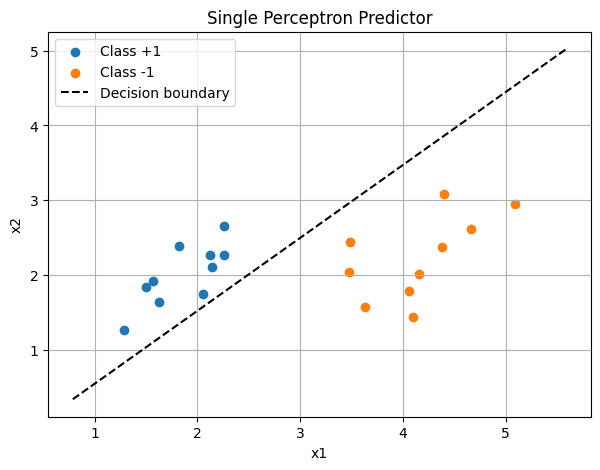

In [111]:
# randomized dataset test
N = 10
means = [[2, 2], [4, 2]]
cov = [[.3, .2], [.2, .3]]
X0 = np.random.multivariate_normal(means[0], cov, N).T
X1 = np.random.multivariate_normal(means[1], cov, N).T

X = np.concatenate((X0, X1), axis=1)
y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis=1)
X = np.concatenate((np.ones((1, 2*N)), X), axis=0)

d = X.shape[0]
model = Perceptron(np.random.randn(d, 1), 200)
(w, m) = model.fit(X, y)
print(f"final weight: {w[-1]}, miss points: {m}")

def visualize():
    plt.figure(figsize=(7, 5))

    plt.scatter(X[1, y[0] == 1], X[2, y[0] == 1], label="Class +1")
    plt.scatter(X[1, y[0] == -1], X[2, y[0] == -1], label="Class -1")

    # Decision boundary: w0 + w1*x1 + w2*x2 = 0
    weights = w[-1].ravel()
    x1 = np.linspace(X[1].min() - 0.5, X[1].max() + 0.5, 200)

    if abs(weights[2]) > 1e-12:
        x2 = -(weights[0] + weights[1] * x1) / weights[2]
        plt.plot(x1, x2, "k--", label="Decision boundary")
    elif abs(weights[1]) > 1e-12:
        # Vertical boundary when the coefficient of x2 is zero
        boundary_x1 = -weights[0] / weights[1]
        plt.axvline(boundary_x1, color="k", linestyle="--", label="Decision boundary")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Single Perceptron Predictor")
    plt.legend()
    plt.grid(True)
    plt.show()
visualize()

3.20

In [134]:
# preprocessing
data = pd.read_csv("./data/passfaildata.csv")
data = data.drop(columns=['student_id'])
data['pass'] = data['pass'].replace(0, -1)
data.head()

X = data.drop(columns=['pass']).to_numpy(dtype="float64")
X = X.T
y = data['pass'].to_numpy(dtype="float64")

d = X.shape[0]
model = Perceptron(np.random.randn(d, 1), 1000)
(w, m) = model.fit(X, y)
# print(X.shape)
print(f"final epoch: {m}")


iter 1, current weight: [[ 25.35512369]
 [  9.73989841]
 [-74.21956851]
 [ 60.33451559]], miss_points = [np.int64(79), np.int64(64), np.int64(22), np.int64(61), np.int64(75), np.int64(2), np.int64(24), np.int64(77), np.int64(11), np.int64(73), np.int64(70), np.int64(42), np.int64(97), np.int64(39), np.int64(13), np.int64(86), np.int64(53), np.int64(82), np.int64(23), np.int64(15), np.int64(65), np.int64(67), np.int64(92), np.int64(84), np.int64(94), np.int64(47), np.int64(76), np.int64(89), np.int64(32), np.int64(51), np.int64(17), np.int64(16), np.int64(25), np.int64(44), np.int64(99), np.int64(55), np.int64(21), np.int64(50), np.int64(85), np.int64(72), np.int64(80), np.int64(91), np.int64(20)]
iter 2, current weight: [[  76.35512369]
 [  44.73989841]
 [-146.21956851]
 [ 116.33451559]], miss_points = [np.int64(23), np.int64(13), np.int64(80), np.int64(24), np.int64(64), np.int64(48), np.int64(17), np.int64(89), np.int64(68), np.int64(86), np.int64(29), np.int64(72), np.int64(2), np.i

In [ ]:
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Use the original 0/1 labels; the custom Perceptron block above uses -1/+1.
X_eval = data.drop(columns=['pass']).to_numpy(dtype='float64')
y_eval = pd.read_csv('./data/passfaildata.csv')['pass'].to_numpy(dtype='int64')

sk_model = make_pipeline(
    StandardScaler(),
    SklearnPerceptron(max_iter=1000, tol=1e-3, random_state=42)
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}
cv_results = cross_validate(sk_model, X_eval, y_eval, cv=cv, scoring=scoring)
metric_names = ['accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1']
fold_scores = pd.DataFrame({name: cv_results[f'test_{name}'] for name in metric_names}, index=[f'Fold {i}' for i in range(1, 6)])
fold_scores.loc['Mean'] = fold_scores.mean()
fold_scores.loc['Std'] = fold_scores.iloc[:5].std()
fold_scores.round(3)


,accuracy,balanced_accuracy,precision,recall,f1
Fold 1,1.000,1.000,1.000,1.0,1.000
Fold 2,1.000,1.000,1.000,1.0,1.000
Fold 3,1.000,1.000,1.000,1.0,1.000
Fold 4,1.000,1.000,1.000,1.0,1.000
Fold 5,0.950,0.938,0.923,1.0,0.960
Mean,0.990,0.988,0.985,1.0,0.992
Std,0.022,0.028,0.034,0.0,0.018
